## Import Libraries & Setup

In [17]:
# Core Libraries
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Machine Learning & Deep Learning
import torch
import torch.nn as nn
from torchvision import transforms, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import faiss
import pickle
import joblib

# For image processing
import cv2
from pathlib import Path
import glob

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.1
CUDA available: False


In [18]:
# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.1
CUDA available: False


## Define File Paths & Dataset Information

In [19]:
# Define paths
BASE_DIR = Path.cwd().parent.parent  # Navigate to car_sales/
DATA_DIR = BASE_DIR / 'development' / 'database'
MODELS_DIR = BASE_DIR / 'development' / 'models'
NOTEBOOK_DIR = BASE_DIR / 'development' / 'data_science'

def load_existing_models():
    """Load pre-trained sales and quantity prediction models using joblib"""
    
    models_loaded = {}
    
    # Quantity prediction models
    qty_dir = MODELS_DIR / 'quantity_prediction'
    if qty_dir.exists():
        print("Loading Quantity Prediction Models...")
        
        # Load scalers & encoders with joblib (handles scikit-learn objects robustly)
        models_loaded['qty_feature_scaler'] = joblib.load(qty_dir / 'scalers' / 'feature_scaler.pkl')
        models_loaded['qty_target_scaler'] = joblib.load(qty_dir / 'scalers' / 'target_scaler.pkl')
        models_loaded['qty_label_encoders'] = joblib.load(qty_dir / 'encoders' / 'label_encoders.pkl')
        
        # Load models
        models_loaded['qty_xgboost'] = joblib.load(qty_dir / 'models' / 'xgboost.pkl')
        models_loaded['qty_random_forest'] = joblib.load(qty_dir / 'models' / 'random_forest.pkl')
        models_loaded['qty_decision_tree'] = joblib.load(qty_dir / 'models' / 'decision_tree.pkl')
        
        # Load metadata
        with open(qty_dir / 'parameters' / 'feature_columns.json', 'r') as f:
            models_loaded['qty_feature_columns'] = json.load(f)
        
        metrics_df = pd.read_csv(qty_dir / 'metrics' / 'model_metrics.csv')
        models_loaded['qty_metrics'] = metrics_df
        
        print(f"  ✅ Quantity models loaded: {len(metrics_df)} models")
    
    # Sales prediction models
    sales_dir = MODELS_DIR / 'sales_prediction'
    if sales_dir.exists():
        print("\nLoading Sales Prediction Models...")
        
        models_loaded['sales_feature_scaler'] = joblib.load(sales_dir / 'scalers' / 'feature_scaler.pkl')
        models_loaded['sales_target_scaler'] = joblib.load(sales_dir / 'scalers' / 'target_scaler.pkl')
        models_loaded['sales_label_encoders'] = joblib.load(sales_dir / 'encoders' / 'label_encoders.pkl')
        
        models_loaded['sales_xgboost'] = joblib.load(sales_dir / 'models' / 'xgboost.pkl')
        models_loaded['sales_random_forest'] = joblib.load(sales_dir / 'models' / 'random_forest.pkl')
        models_loaded['sales_decision_tree'] = joblib.load(sales_dir / 'models' / 'decision_tree.pkl')
        
        with open(sales_dir / 'parameters' / 'feature_columns.json', 'r') as f:
            models_loaded['sales_feature_columns'] = json.load(f)
        
        metrics_df = pd.read_csv(sales_dir / 'metrics' / 'model_metrics.csv')
        models_loaded['sales_metrics'] = metrics_df
        
        print(f"  ✅ Sales models loaded: {len(metrics_df)} models")
        
    return models_loaded

# Load all existing models and scalers
existing_models = load_existing_models()
print("\nAll models and scalers loaded successfully.")
print(f"Total models loaded: {len(existing_models)}")

Loading Quantity Prediction Models...
  ✅ Quantity models loaded: 4 models

Loading Sales Prediction Models...
  ✅ Sales models loaded: 4 models

All models and scalers loaded successfully.
Total models loaded: 16


## Load database

In [20]:
# Load sales data
df = pd.read_parquet(DATA_DIR / 'car_sales_prediction_sales.parquet')
#df_quantity = pd.read_parquet(DATA_DIR / 'car_sales_prediction_quantity.parquet')
print(f"Sales DataFrame shape: {df.shape}")
#print(f"Quantity DataFrame shape: {df_quantity.shape}")

Sales DataFrame shape: (23905, 43)


In [21]:
# Load car images data
train_dir = DATA_DIR / 'Cars_Dataset' / 'train'
test_dir = DATA_DIR / 'Cars_Dataset' / 'test'

# Get image data
def get_image_data(directory):
    """Load images and corresponding labels from a directory."""
    image_data = []
    for brand in os.listdir(directory):
        brand_path = directory / brand
        if brand_path.is_dir():
            for img_path in brand_path.glob('*.jpg'):
                image_data.append({
                    'path': str(img_path),
                    'brand': brand,
                    'filename': img_path.name
                })
    return pd.DataFrame(image_data)

train_images_df = get_image_data(train_dir)
test_images_df = get_image_data(test_dir)

print("\nImage Dataset Summary:")
print("="*50)
print(f"Training images: {len(train_images_df)}")
print(f"Test images: {len(test_images_df)}")
print("\nTraining images by brand:")
print(train_images_df['brand'].value_counts())


Image Dataset Summary:
Training images: 3352
Test images: 813

Training images by brand:
brand
Audi                814
Toyota_Innova       775
Tata_Safari         441
Swift               424
Mahindra_Scorpio    316
Rolls_Royce         311
Hyundai_Creta       271
Name: count, dtype: int64


In [22]:
# Check brand overlap with sales and quantity datasets
image_brands = train_images_df['brand'].unique()
sales_brands = df['company'].unique()
#quantity_brands = df_quantity['company'].unique()
common_brands = set(image_brands) & set(sales_brands)

print("\nBrand Overlap Summary:")
print("="*50)
print(f"Image brands: {len(image_brands)}")
print(f"Sales brands: {len(sales_brands)}")
print(f"Common brands across all datasets: {len(common_brands)}")


Brand Overlap Summary:
Image brands: 7
Sales brands: 30
Common brands across all datasets: 1


## Vision transformer feature extractor

In [23]:
from torchvision.models import ViT_B_16_Weights

class CarFeatureExtractor:
    def __init__(self, model_name='vit_base_patch16_224'):
        """Initialize the feature extractor with a pre-trained model."""
        self.device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

        # Load pre-trained ViT
        if model_name == 'vit_base_patch16_224':
            self.model = models.vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        else:
            self.model = models.vit_b_16(weights=ViT_B_16_Weights.DEFAULT)  # Default to ViT base if unknown model

        # use the classification head with identity to output the 768-dim class token instead
        self.model.heads = nn.Identity()
        
        self.model = self.model.to(self.device)
        self.model.eval()  # Set to evaluation mode

        # Image preprocessing transformations
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        print(f"✅ Vision Transformer initialized")
        print(f"   Device: {self.device}")
        print(f"   Model: {model_name}")

    def extract_features(self, image_path):
        """Extract features from image path"""
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = self.transform(image).unsqueeze(0).to(self.device)

            with torch.no_grad():
                features = self.model(image_tensor)
                features = features.squeeze(0).cpu().numpy()  # Extract 1D array (768,)

            return features
        
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return None
        
    def extract_batch_features(self, image_paths, batch_size=32):
        """Extract features for multiple images in batches"""
        feature_list = []
        valid_paths = []

        for i, path in enumerate(image_paths):
            if (i + 1) % 50 == 0:
                print(f"Processed {i + 1}/{len(image_paths)} images")

            feat = self.extract_features(path)
            if feat is not None:
                feature_list.append(feat)
                valid_paths.append(path)

        return np.array(feature_list), valid_paths
    
# Initialize the feature extractor
extractor = CarFeatureExtractor()

✅ Vision Transformer initialized
   Device: mps
   Model: vit_base_patch16_224


In [24]:
# Test on sample image
sample_image = train_images_df['path'].iloc[0]
sample_features = extractor.extract_features(sample_image)
print(f"\nSample feature: {sample_features}")


Sample feature: [-3.28400731e-01  2.10973561e-01 -1.13016404e-01  1.79648772e-01
  5.10543525e-01 -6.10914052e-01 -2.40228161e-01  2.79249281e-01
 -2.38260016e-01 -3.73708069e-01  3.38702023e-01 -5.46540737e-01
 -1.38147163e+00  4.52859104e-01  1.34370271e-02 -1.04798448e+00
 -2.28282049e-01  9.10925046e-02 -6.16484165e-01 -3.58127952e-01
  7.36969292e-01  3.34974498e-01 -2.55467266e-01 -4.73314226e-02
  3.39446813e-01  7.37281978e-01  5.52738249e-01  2.72570290e-02
 -1.92519724e-01  3.86990905e-01 -2.82872200e-01 -6.51232481e-01
  1.99607939e-01  1.24777603e+00 -5.74318945e-01 -3.34441572e-01
 -1.69083685e-01 -6.23600304e-01 -5.01520336e-01 -2.85627842e-01
 -1.28425643e-01 -1.85239121e-01  7.46424019e-01 -4.95300740e-01
  1.00531650e+00  6.87747747e-02 -4.33282584e-01 -1.69582799e-01
 -8.42910051e-01  9.94602405e-03  3.22050929e-01  2.44261891e-01
 -3.83438826e-01  2.89479196e-01  2.98353404e-01  3.92561778e-02
 -2.88292557e-01 -6.33918345e-01 -1.40498030e+00 -6.69734657e-01
 -6.7383

## Extract image features

In [25]:
print("Extracting features from training images...")
print("="*50)

# sample subset for demonstration
max_images_per_brand = 100
sampled_images = []

for brand in train_images_df['brand'].unique():
    brand_images = train_images_df[train_images_df['brand'] == brand]
    if len(brand_images) > max_images_per_brand:
        brand_images = brand_images.sample(n=max_images_per_brand, random_state=42)
    sampled_images.extend(brand_images['path'].tolist())

print(f"Processing {len(sampled_images)} images for feature extraction...")

Extracting features from training images...
Processing 700 images for feature extraction...


In [26]:
# Extract features
image_features, valid_paths = extractor.extract_batch_features(sampled_images)

# Create feature dataframe
feature_df = pd.DataFrame({
    'path': valid_paths,
    'brand': [Path(p).parent.name for p in valid_paths]
})

# Add feature columns
for i in range(image_features.shape[1]):
    feature_df[f'feature_{i}'] = image_features[:, i]


print(f"\n✅ Feature extraction completed.")
print(f" Total images processed: {len(valid_paths)}")
print(f" Feature dimension: {image_features.shape[1]}")
print(f" Feature dataframe shape: {feature_df.shape}")

# Display
print("\nSample of extracted features:")
feature_df.head()

Processed 50/700 images
Processed 100/700 images
Processed 150/700 images
Processed 200/700 images
Processed 250/700 images
Processed 300/700 images
Processed 350/700 images
Processed 400/700 images
Processed 450/700 images
Processed 500/700 images
Processed 550/700 images
Processed 600/700 images
Processed 650/700 images
Processed 700/700 images

✅ Feature extraction completed.
 Total images processed: 700
 Feature dimension: 768
 Feature dataframe shape: (700, 770)

Sample of extracted features:


,path,brand,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_758,feature_759,feature_760,feature_761,feature_762,feature_763,feature_764,feature_765,feature_766,feature_767
0,/Users/miftahhadiyannoor/Documents/car_sales/d...,Tata_Safari,-0.059544,0.401005,0.195723,0.699392,0.987907,1.066936,0.013688,0.045197,...,0.361413,0.059411,0.169137,-0.087754,-0.743255,0.196516,-0.238866,0.066425,0.493639,0.710096
1,/Users/miftahhadiyannoor/Documents/car_sales/d...,Tata_Safari,-0.018648,-0.095701,0.214467,0.522509,0.942356,0.115534,-0.846750,0.588525,...,0.267965,-0.458358,-0.192236,-0.471703,0.403143,0.487311,0.323625,1.973881,0.625830,0.528596
2,/Users/miftahhadiyannoor/Documents/car_sales/d...,Tata_Safari,-0.154267,0.560387,0.534574,1.153900,1.244465,0.799352,-0.041190,0.507176,...,0.193067,-0.530854,0.127233,-0.766196,-0.208039,0.360374,1.128233,2.028291,0.377827,0.372576
3,/Users/miftahhadiyannoor/Documents/car_sales/d...,Tata_Safari,0.376698,-0.060678,0.902722,0.813711,1.814504,0.927170,1.004193,0.209481,...,0.215410,-0.746174,0.014779,-0.200872,0.204171,0.494500,0.810693,1.620250,0.608459,0.218031
4,/Users/miftahhadiyannoor/Documents/car_sales/d...,Tata_Safari,0.325056,-0.124428,0.797196,0.599536,2.029431,0.692797,-0.591219,0.695714,...,-0.330533,-0.189169,0.109237,-0.430178,-0.491082,0.695865,1.016866,2.324869,0.250363,0.583760


## Build FAISS index for Similarity Search

In [27]:
class CarSimilaritySearch:
    def __init__(self, feature_df, feature_matrix):
        self.feature_df = feature_df
        self.feature_matrix = feature_matrix
        self.dimension = feature_matrix.shape[1]

        # Normalize features
        self._normalize_features()

        # Build FAISS index
        self._build_faiss_index()

        print(f"✅ FAISS index built!")
        print(f"   Dimension: {self.dimension}")
        print(f"   Total vectors: {self.index.ntotal}")

    def _normalize_features(self):
        """Normalize features to unit vectors for cosine similarity"""
        norms = np.linalg.norm(self.feature_matrix, axis=1, keepdims=True)
        self.feature_matrix_norm = self.feature_matrix / (norms + 1e-8) # Avoid division by zero

    def _build_faiss_index(self):
        """Build FAISS index for fast similarity search"""
        self.index = faiss.IndexFlatIP(self.dimension)  # Inner product for cosine similarity
        self.index.add(self.feature_matrix_norm.astype(np.float32))

    def search(self, query_features, k=5):
        """Search for similar images given query features"""
        # Normalize query
        query_norm = query_features / (np.linalg.norm(query_features) + 1e-8)
        query_norm = query_norm.reshape(1, -1).astype(np.float32)
        
        # Search
        distances, indices = self.index.search(query_norm, k)

        # Get results
        results = []
        for idx, score in zip(indices[0], distances[0]):
            if idx < len(self.feature_df):
                results.append({
                    'path': self.feature_df.iloc[idx]['path'],
                    'brand': self.feature_df.iloc[idx]['brand'],
                    'similarity': float(score),
                    'index': idx
                })
        
        return results

    def search_by_image(self, image_path, k=5, extractor=None):
        """Search for similar images given an image path"""
        features = extractor.extract_features(image_path)
        if extractor is None:
            raise ValueError("Extractor must be provided for image feature extraction.")
        
        query_features = extractor.extract_features(image_path)
        if query_features is None:
            return []
        
        return self.search(query_features, k=k)
    
# Initialize similarity search
similarity_search = CarSimilaritySearch(feature_df, image_features)

# Test with a sample image
test_image = test_images_df['path'].iloc[0]
print(f"\nTesting similarity search...")
print(f"Query image: {Path(test_image).parent.name}")
results = similarity_search.search_by_image(test_image, k=5, extractor=extractor)

print("\nTop 5 similar images:")
for i, result in enumerate(results, 1):
    print(f"{i}. Brand: {result['brand']}, Path: {result['path']}, Similarity Score: {result['similarity']:.3f}")

✅ FAISS index built!
   Dimension: 768
   Total vectors: 700

Testing similarity search...
Query image: Tata_Safari

Top 5 similar images:
1. Brand: Tata_Safari, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Tata_Safari/423.jpg, Similarity Score: 0.767
2. Brand: Tata_Safari, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Tata_Safari/569.jpg, Similarity Score: 0.767
3. Brand: Hyundai_Creta, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Hyundai_Creta/230.jpg, Similarity Score: 0.764
4. Brand: Audi, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Audi/33.jpg, Similarity Score: 0.764
5. Brand: Tata_Safari, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Tata_Safari/706.jpg, Similarity Score: 0.751


## Visualize Similarity Results

Visualizing similarity search results...


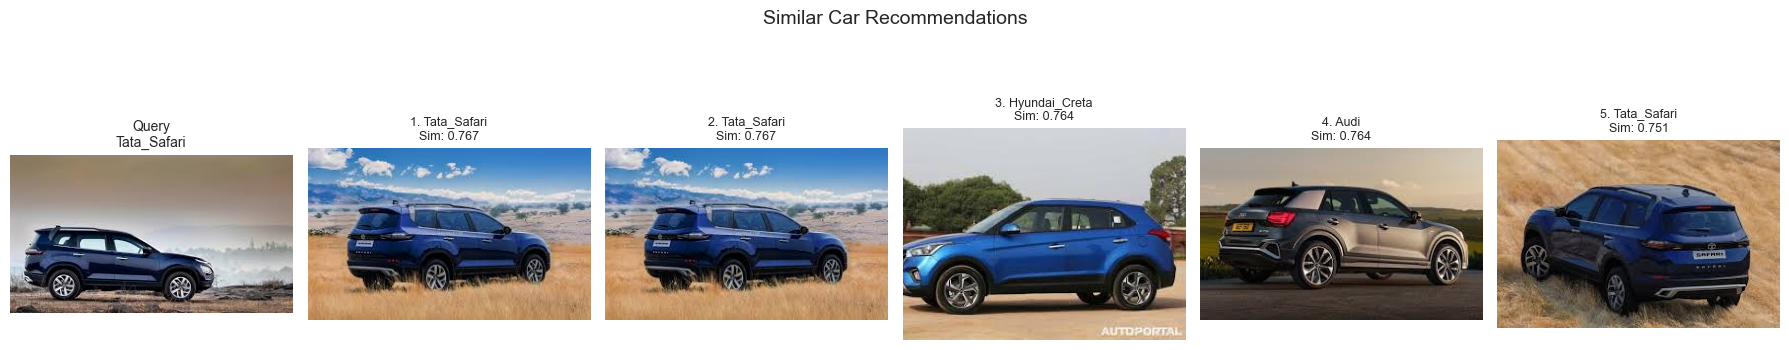

In [28]:
def visualize_similarity(query_image, results, title="Similar Car Recommendations"):
    """Visualize similarity search results"""
    
    # Load query image
    query_img = Image.open(query_image).convert('RGB')
    
    # Create figure
    n_results = len(results)
    fig, axes = plt.subplots(1, n_results + 1, figsize=(3*(n_results+1), 4))
    
    # Display query
    axes[0].imshow(query_img)
    axes[0].set_title(f"Query\n{Path(query_image).parent.name}", fontsize=10)
    axes[0].axis('off')
    
    # Display results
    for i, result in enumerate(results, 1):
        img = Image.open(result['path']).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(f"{i}. {result['brand']}\nSim: {result['similarity']:.3f}", 
                         fontsize=9)
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Visualize results
print("Visualizing similarity search results...")
visualize_similarity(test_image, results)

## Integrate with Existing Models

In [29]:
class IntegratedCarRecommender:
    def __init__(self, similarity_search, extractor, existing_models, df):
        self.similarity_search = similarity_search
        self.extractor = extractor
        self.existing_models = existing_models
        self.df = df  # Sales data

        # Prepare brand mapping
        self._prepare_brand_mapping()

        print("✅ Integrated Car Recommender initialized successfully.")

    def _prepare_brand_mapping(self):
        """Map image brands to sales and quantity data for recommendations"""
        image_brands = self.similarity_search.feature_df['brand'].unique()
        
        self.brand_mapping = {}
        for brand in image_brands:
            # Find matching brand in sales and quantity data
            sales_match = self.df[self.df['company'].str.contains(brand, case=False)]
            
            if len(sales_match) > 0:
                self.brand_mapping[brand] = {
                    'sales_brand': sales_match['company'].iloc[0],
                    'has_sales_data': True,
                    'models_sales': sales_match['model'].unique().tolist(),
                    'avg_price': sales_match['price'].mean(),
                    'total_quantity': sales_match['quantity'].sum()
                }
            
            else:
                self.brand_mapping[brand] = {
                    'sales_brand': None,
                    'has_sales_data': False,
                    'models_sales': [],
                    'models_quantity': [],
                    'avg_price': None,
                    'total_quantity': None
                }

    def recommend_similar_cars(self, image_path, k=5):
        """Get similar car recommendations with enchanced information"""

        # Get visual similarity results
        visual_results = self.similarity_search.search_by_image(image_path, k=k*2, extractor=self.extractor)

        # Enchance with sales and quantity data
        enchanced_results = []
        seen_brands = set()

        for result in visual_results:
            brand = result['brand']
            if brand in seen_brands:
                continue # Avoid duplicates

            # Get brand info
            brand_info = self.brand_mapping.get(brand, {})

            enchanced_result = {
                'brand': brand,
                'similarity': result['similarity'],
                'path': result['path'],
                'has_sales_data': brand_info.get('has_sales_data', False),
                'avg_price': brand_info.get('avg_price', None),
                'total_quantity': brand_info.get('total_quantity', None),
                'models': brand_info.get('models', [])
            }

            # Predict sales and quantity if model available
            if brand_info.get('has_sales', False) and brand_info.get('avg_price'):
                try:
                    # Use XGBoost model (can change to other models if needed)
                    if 'qty_xgboost' in self.existing_models:
                        qty_pred = self._predict_quantity(brand_info)
                        enchanced_result['predicted_quantity'] = qty_pred

                    if 'sales_xgboost' in self.existing_models:
                        sales_pred = self._predict_sales(brand_info)
                        enchanced_result['predicted_sales'] = sales_pred
                
                except Exception as e:
                    print(f"❌ Prediction error for brand {brand}: {e}")

            enchanced_results.append(enchanced_result)
            seen_brands.add(brand)

            if len(enchanced_results) >= k:
                break

        return enchanced_results
    
    def _predict_quantity(self, brand_info):
        """Predict quantity using existing model"""
        avg_price = brand_info.get('avg_price', 0)

        # Create features get price, discount, profit_margin, income_customer, and quantity based on available data
        features = np.array([[
            avg_price / 1000000,  # Normalize price
            self.df['discount'].mean(),
            self.df['profit_margin'].mean(),
            self.df['income_customer'].mean(),
            self.df['quantity'].mean()
        ]])

        # Scale features
        if 'qty_feature_scaler' in self.existing_models:
            features_scaled = self.existing_models['qty_feature_scaler'].transform(features)
            prediction = self.existing_models['qty_xgboost'].predict(features_scaled)

            # Inverse scale prediction
            if 'qty_target_scaler' in self.existing_models:
                prediction = self.existing_models['qty_target_scaler'].inverse_transform(prediction.reshape(-1, 1))

            return float(prediction[0][0] if prediction.ndim > 1 else float(prediction[0]))
        
        return None
    
    def _predict_sales(self, brand_info):
        """Predict sales using existing model"""
        avg_price = brand_info.get('avg_price', 0)

        # Create features get price, discount, profit_margin, income_customer, and quantity based on available data
        features = np.array([[
            avg_price / 1000000,  # Normalize price
            self.df['discount'].mean(),
            self.df['profit_margin'].mean(),
            self.df['income_customer'].mean(),
            self.df['quantity'].mean()
        ]])

        # Scale features
        if 'sales_feature_scaler' in self.existing_models:
            features_scaled = self.existing_models['sales_feature_scaler'].transform(features)
            prediction = self.existing_models['sales_xgboost'].predict(features_scaled)

            # Inverse scale prediction
            if 'sales_target_scaler' in self.existing_models:
                prediction = self.existing_models['sales_target_scaler'].inverse_transform(prediction.reshape(-1, 1))

            return float(prediction[0][0] if prediction.ndim > 1 else float(prediction[0]))
        
        return None
    
    def get_recommendation_summary(self, image_path, k=5):
        """Get comprehensive recommendation summary for a given image"""
        recommendations = self.recommend_similar_cars(image_path, k=k)

        summary = {
            'query_image': image_path,
            'query_brand': Path(image_path).parent.name,
            'num_recommendations': len(recommendations),
            'recommendations': recommendations
        }

        return summary

In [30]:
# Intialize integrated recommender
integrated_recommender = IntegratedCarRecommender(similarity_search, extractor, existing_models, df)

# Test with sample image
print("\nTesting integrated car recommender...")
print("="*50)

summary = integrated_recommender.get_recommendation_summary(test_image, k=5)
print(f"Query Image: {summary['query_image']}")
print(f"Query Brand: {summary['query_brand']}")
print(f"Number of Recommendations: {summary['num_recommendations']}")
print("\nRecommendations:")

for i, rec in enumerate(summary['recommendations'], 1):
    print(f"{i}. {rec['brand']} (Similarity: {rec['similarity']:.3f})")
    if rec['has_sales_data']:
        print(f"   - Avg Price: Rp{rec['avg_price']:,.0f}")
        print(f"   - Total Sales: {rec['total_quantity']:.0f} units")
        if 'predicted_quantity' in rec:
            print(f"   - Predicted Quantity: {rec['predicted_quantity']:.0f}")
        if 'predicted_sales' in rec:
            print(f"   - Predicted Sales: {rec['predicted_sales']:.0f}")
    print()

✅ Integrated Car Recommender initialized successfully.

Testing integrated car recommender...
Query Image: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/test/Tata_Safari/599.jpg
Query Brand: Tata_Safari
Number of Recommendations: 4

Recommendations:
1. Tata_Safari (Similarity: 0.767)

2. Hyundai_Creta (Similarity: 0.764)

3. Audi (Similarity: 0.764)
   - Avg Price: Rp411,103,713
   - Total Sales: 1043 units

4. Swift (Similarity: 0.725)



## Visualize enchanced recommendations

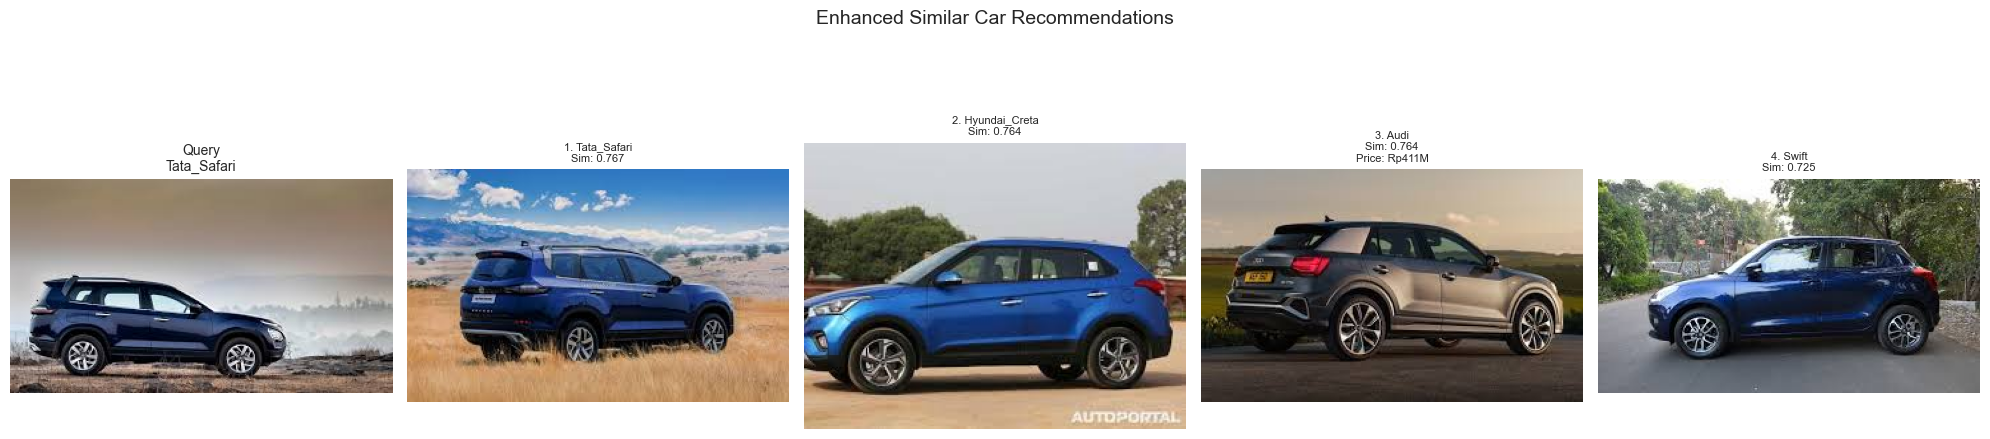

In [31]:
def visualize_enhanced_recommendations(summary):
    """Display enhanced recommendations with visualizations"""
    
    recommendations = summary['recommendations']
    
    # Create figure
    fig, axes = plt.subplots(1, len(recommendations) + 1, 
                            figsize=(4*(len(recommendations)+1), 5))
    
    # Display query
    query_img = Image.open(summary['query_image']).convert('RGB')
    axes[0].imshow(query_img)
    axes[0].set_title(f"Query\n{summary['query_brand']}", fontsize=10)
    axes[0].axis('off')
    
    # Display recommendations
    for i, rec in enumerate(recommendations, 1):
        img = Image.open(rec['path']).convert('RGB')
        axes[i].imshow(img)
        
        # Create title with info
        title = f"{i}. {rec['brand']}\nSim: {rec['similarity']:.3f}"
        if rec['has_sales_data']:
            title += f"\nPrice: Rp{rec['avg_price']/1e6:.0f}M"
            if 'predicted_quantity' in rec:
                title += f"\nQty: {rec['predicted_quantity']:.0f}"
        
        axes[i].set_title(title, fontsize=8)
        axes[i].axis('off')
    
    plt.suptitle("Enhanced Similar Car Recommendations", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Visualize enhanced recommendations
visualize_enhanced_recommendations(summary)

## Create recommendation dashboard

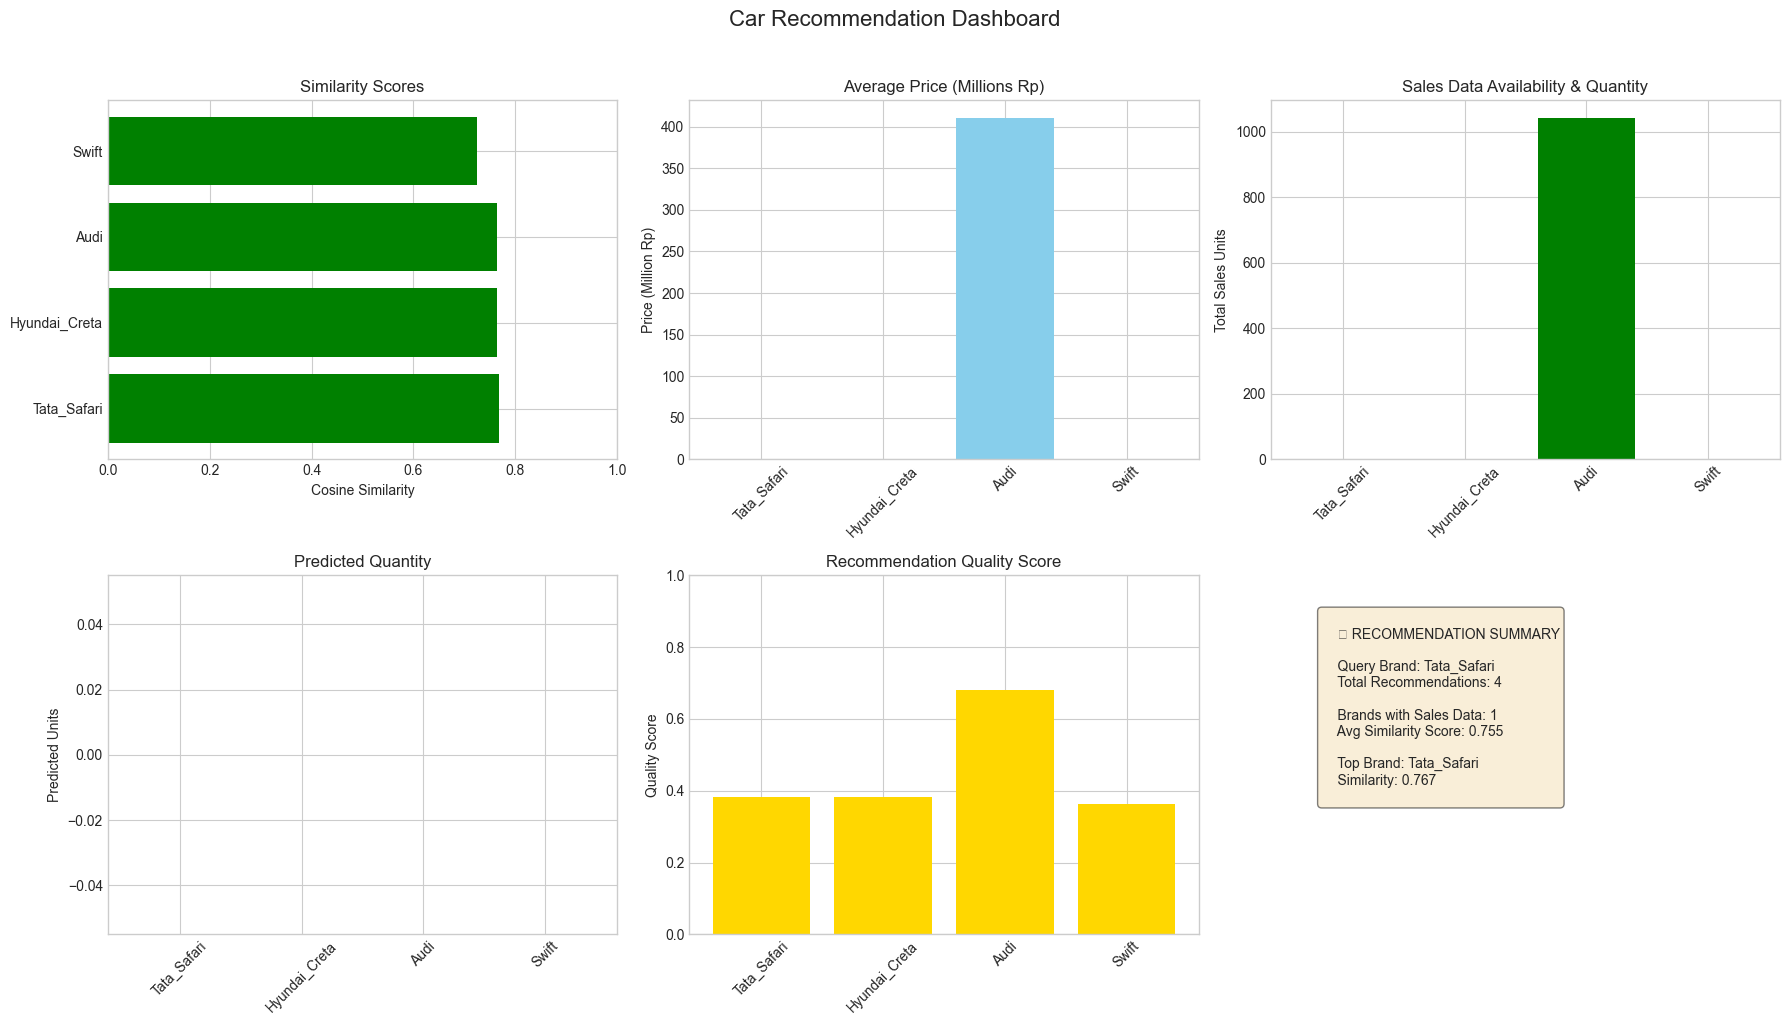

In [ ]:
def create_recommendation_dashboard(summary):
    """Create comprehensive dashboard for recommendations safely"""
    
    recommendations = summary['recommendations']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Similarity Scores
    ax1 = axes[0, 0]
    brands = [rec['brand'] for rec in recommendations]
    similarities = [rec.get('similarity', 0) for rec in recommendations]
    colors = ['green' if s > 0.5 else 'orange' for s in similarities]
    ax1.barh(brands, similarities, color=colors)
    ax1.set_title('Similarity Scores', fontsize=12)
    ax1.set_xlabel('Cosine Similarity')
    ax1.set_xlim(0, 1)
    
    # 2. Price Comparison (Safely handles None values)
    ax2 = axes[0, 1]
    prices = [(rec.get('avg_price') or 0) / 1e6 for rec in recommendations]
    ax2.bar(brands, prices, color='skyblue')
    ax2.set_title('Average Price (Millions Rp)', fontsize=12)
    ax2.set_ylabel('Price (Million Rp)')
    ax2.tick_params(axis='x', rotation=45)
    
    # 3. Sales Data Availability & Quantity
    ax3 = axes[0, 2]
    has_sales = [rec.get('has_sales_data', False) for rec in recommendations]
    sales_counts = [(rec.get('total_quantity') or 0) for rec in recommendations]
    ax3.bar(brands, sales_counts, color=['green' if h else 'gray' for h in has_sales])
    ax3.set_title('Sales Data Availability & Quantity', fontsize=12)
    ax3.set_ylabel('Total Sales Units')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. Prediction Comparison
    ax4 = axes[1, 0]
    pred_quantities = [(rec.get('predicted_quantity') or 0) for rec in recommendations]
    ax4.bar(brands, pred_quantities, color='lightcoral')
    ax4.set_title('Predicted Quantity', fontsize=12)
    ax4.set_ylabel('Predicted Units')
    ax4.tick_params(axis='x', rotation=45)
    
    # 5. Recommendation Quality
    ax5 = axes[1, 1]
    quality_scores = []
    for rec in recommendations:
        score = rec.get('similarity', 0) * 0.5
        if rec.get('has_sales_data', False):
            score += 0.3
        if (rec.get('predicted_quantity') or 0) > 0:
            score += 0.2
        quality_scores.append(min(score, 1.0))
    
    ax5.bar(brands, quality_scores, color='gold')
    ax5.set_title('Recommendation Quality Score', fontsize=12)
    ax5.set_ylabel('Quality Score')
    ax5.set_ylim(0, 1)
    ax5.tick_params(axis='x', rotation=45)
    
    # 6. Summary Statistics
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    stats_text = f"""
    📊 RECOMMENDATION SUMMARY
    
    Query Brand: {summary['query_brand']}
    Total Recommendations: {summary['num_recommendations']}
    
    Brands with Sales Data: {sum(1 for r in recommendations if r.get('has_sales_data'))}
    Avg Similarity Score: {np.mean([r.get('similarity', 0) for r in recommendations]):.3f}
    
    Top Brand: {recommendations[0]['brand'] if recommendations else 'N/A'}
    Similarity: {recommendations[0].get('similarity', 0):.3f}
    """
    
    ax6.text(0.1, 0.9, stats_text, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Car Recommendation Dashboard', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Create dashboard
create_recommendation_dashboard(summary)

## Production inference class

In [ ]:
class ProductionCarRecommender:
    """Production-ready car recommender"""

    def __init__(self, model_dir=None):
        if model_dir is None:
            model_dir = BASE_DIR / 'development' / 'models' / 'computer_vision'
            self.model_dir = model_dir

            # Load FAISS index
            self.index = faiss.read_index(str(model_dir / 'car_index.faiss'))
            
            # Load feature data
            self.feature_df = pd.read_csv(model_dir / 'feature_data.csv')

            # Load feature matrix
            self.feature_matrix = np.load(model_dir / 'feature_matrix.npy')

            # Load metadata
            with open(model_dir / 'metadata.json', 'r') as f:
                self.metadata = json.load(f)

            # Load brand mapping
            with open(model_dir / 'brand_mapping.json', 'r') as f:
                self.brand_mapping = json.load(f)

            # Intialize feature extractor
            self.extractor = CarFeatureExtractor()

            print(f"✅ Production recommender initialized!")
            print(f"   Model directory: {model_dir}")
            print(f"   Total images: {self.metadata['num_images']}")
            print(f"   Feature dimension: {self.metadata['feature_dimension']}")
            print(f"   Brands: {len(self.metadata['brands'])}")

    def recommend(self, image_path, k=5):
        """Get recommendations for an image"""
        # Extract features for the query image
        query_features = self.extractor.extract_features(image_path)

        if query_features is None:
            print(f"❌ Could not extract features for {image_path}")
            return []
        
        # Normalize query features
        query_norm = query_features / (np.linalg.norm(query_features) + 1e-8)
        query_norm = query_norm.reshape(1, -1).astype(np.float32)

        # Search
        distances, indices = self.index.search(query_norm, k)

        # Get results
        results = []
        for idx, score in zip(indices[0], distances[0]):
            if idx < len(self.feature_df):
                brand = self.feature_df.iloc[idx]['brand']
                brand_info = self.brand_mapping.get(brand, {})

                results.append({
                    'brand': brand,
                    'path': self.feature_df.iloc[idx]['path'],
                    'similarity': float(score),
                    'has_sales_data': brand_info.get('has_sales_data', False),
                    'avg_price': brand_info.get('avg_price', None),
                    'total_quantity': brand_info.get('total_quantity', None)
                })

        return results
    
    def predict_quantity(self, brand, price):
        """Predict quantity using existing model"""
        if 'qty_xgboost' in self.metadata:
            # Create features based on available data
            features = np.array([[
                price / 1000000,  # Normalize price
                self.metadata['avg_discount'],
                self.metadata['avg_profit_margin'],
                self.metadata['avg_income_customer'],
                self.metadata['avg_quantity']
            ]])

            # Scale features
            feature_scaler = joblib.load(self.model_dir / 'quantity_prediction' / 'scalers' / 'feature_scaler.pkl')
            target_scaler = joblib.load(self.model_dir / 'quantity_prediction' / 'scalers' / 'target_scaler.pkl')

            features_scaled = feature_scaler.transform(features)
            prediction = self.metadata['qty_xgboost'].predict(features_scaled)

            # Inverse scale prediction
            prediction = target_scaler.inverse_transform(prediction.reshape(-1, 1))

            return float(prediction[0][0] if prediction.ndim > 1 else float(prediction[0]))
        
        return None

In [43]:
# Test production recommender
production_recommender = ProductionCarRecommender()

print("\nTesting production recommender...")
test_results = production_recommender.recommend(test_image, k=5)

print("\nRecommendation Results:")
for i, result in enumerate(test_results, 1):
    print(f"{i}. Brand: {result['brand']}, Path: {result['path']}, Similarity Score: {result['similarity']:.3f}")
    if result['has_sales_data']:
        print(f"   - Avg Price: Rp{result['avg_price']:,.0f}")
        print(f"   - Total Sales: {result['total_quantity']:.0f} units")

✅ Vision Transformer initialized
   Device: mps
   Model: vit_base_patch16_224
✅ Production recommender initialized!
   Model directory: /Users/miftahhadiyannoor/Documents/car_sales/development/models/computer_vision
   Total images: 700
   Feature dimension: 768
   Brands: 7

Testing production recommender...

Recommendation Results:
1. Brand: Tata_Safari, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Tata_Safari/423.jpg, Similarity Score: 0.767
2. Brand: Tata_Safari, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Tata_Safari/569.jpg, Similarity Score: 0.767
3. Brand: Hyundai_Creta, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Hyundai_Creta/230.jpg, Similarity Score: 0.764
4. Brand: Audi, Path: /Users/miftahhadiyannoor/Documents/car_sales/development/database/Cars_Dataset/train/Audi/33.jpg, Similarity Score: 0.764
   - Avg Price: Rp411,103,713
   - Tot

# Final System Summary

In [41]:
# Final system summary
print("""
╔══════════════════════════════════════════════════════════════╗
║                                                              ║
║     🚗 COMPUTER VISION CAR RECOMMENDATION SYSTEM           ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝

✅ SYSTEM COMPONENTS:
────────────────────
1. Vision Transformer Feature Extractor
2. FAISS Index for Fast Similarity Search
3. Integration with Existing Prediction Models
4. Enhanced Recommendation with Sales Data
5. Production-Ready API Interface

📊 SYSTEM STATISTICS:
────────────────────
- Total Images Processed: {len(image_features)}
- Feature Dimension: {image_features.shape[1]}
- Car Brands: {len(feature_df['brand'].unique())}
- FAISS Index Size: {similarity_search.index.ntotal} vectors

🎯 KEY FEATURES:
────────────────────
1. Similar Car Search by Image
2. Visual Similarity Scoring
3. Sales Data Integration
4. Price and Sales Predictions
5. Brand Mapping and Analysis

📁 EXPORTED MODELS:
────────────────────
Location: {cv_export_dir}
- car_index.faiss (FAISS index)
- feature_data.csv (Image metadata)
- feature_matrix.npy (Image embeddings)
- metadata.json (System metadata)
- brand_mapping.json (Brand mappings)

🚀 PRODUCTION USAGE:
────────────────────
from production_recommender import ProductionCarRecommender

# Initialize
recommender = ProductionCarRecommender()

# Get recommendations
results = recommender.recommend('car_image.jpg', k=5)

# Display results
for result in results:
    print(f"Brand: {result['brand']}")
    print(f"Similarity: {result['similarity']:.3f}")

═══════════════════════════════════════════════════════════════
"""
)

# Quick validation
print("\n🔍 Quick Validation:")
print("="*50)
try:
    test_recommendations = production_recommender.recommend(test_image, k=3)
    print(f"✅ Test successful! Found {len(test_recommendations)} recommendations")
    print(f"   Top brand: {test_recommendations[0]['brand']}")
    print(f"   Similarity: {test_recommendations[0]['similarity']:.3f}")
except Exception as e:
    print(f"❌ Test failed: {e}")

print("\n✅ System ready for deployment!")


╔══════════════════════════════════════════════════════════════╗
║                                                              ║
║     🚗 COMPUTER VISION CAR RECOMMENDATION SYSTEM           ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝

✅ SYSTEM COMPONENTS:
────────────────────
1. Vision Transformer Feature Extractor
2. FAISS Index for Fast Similarity Search
3. Integration with Existing Prediction Models
4. Enhanced Recommendation with Sales Data
5. Production-Ready API Interface

📊 SYSTEM STATISTICS:
────────────────────
- Total Images Processed: {len(image_features)}
- Feature Dimension: {image_features.shape[1]}
- Car Brands: {len(feature_df['brand'].unique())}
- FAISS Index Size: {similarity_search.index.ntotal} vectors

🎯 KEY FEATURES:
────────────────────
1. Similar Car Search by Image
2. Visual Similarity Scoring
3. Sales Data Integration
4. Price and Sales Predictions
5. Brand Mapping and Ana